In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.io as sio  # <-- Added for .mat files
from scipy import signal
from scipy.linalg import eigh
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import mne  
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# Suppress MNE warnings for cleaner notebook output
mne.set_log_level('ERROR')

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using {device}")

## Step 0: Data Loading Function for Mixed Formats (.mat Train / .gdf Eval)
DATA_DIR = '/Users/ashokvarmabevara/MtechProj/BCI Competition IV/' 

import scipy.io as sio

def load_bci4_2a(data_dir, subject=1, is_training=True):
    """Loads BCI Comp IV 2a data: .mat for training, .gdf for evaluation."""
    
    if is_training:
        # --- LOAD .MAT FILE (TRAINING - BNCI Horizon 2020 format) ---
        filename = f'A{subject:02d}T.mat'
        filepath = os.path.join(data_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Could not find {filepath}. Check your DATA_DIR.")
            
        print(f"Loading MATLAB file: {filename}...")
        
        # simplify_cells=True is crucial! It turns ugly MATLAB structs into standard Python dicts
        mat = sio.loadmat(filepath, simplify_cells=True)
        
        if 'data' not in mat:
            raise KeyError(f"Expected 'data' key in .mat file. Found: {list(mat.keys())}")
            
        data = mat['data']
        X_all, y_all = [], []
        
        # The BNCI .mat file contains 9 runs. 
        # Runs 0-2 are EOG/Calibration. Runs 3-8 are the actual Motor Imagery trials.
        for run in data:
            # Check if this run is a motor imagery run (contains X, trial, and y)
            if isinstance(run, dict) and 'X' in run and 'trial' in run and 'y' in run:
                X_cont = run['X']       # Continuous data: (samples, channels)
                trials = run['trial']   # Starting sample index of each trial
                labels = run['y']       # Labels for each trial (1-4)
                
                # Slicing out the epochs
                for i, start_idx in enumerate(trials):
                    # Cue appears at t=2s (500 samples at 250Hz). 
                    # We want the 4 seconds of MI following the cue (1000 samples).
                    start = int(start_idx) + 500
                    end = start + 1000
                    
                    if end <= X_cont.shape[0]:
                        # Grab the first 22 channels (EEG) and transpose to (22, 1000)
                        epoch = X_cont[start:end, :22].T
                        X_all.append(epoch)
                        y_all.append(labels[i])
                        
        if not X_all:
            raise ValueError("Could not extract any trials. Check the internal structure of your .mat file.")
            
        X = np.array(X_all, dtype=np.float32)
        y = np.array(y_all, dtype=np.int64)

        # Convert labels from 1-4 to 0-3 for PyTorch
        if np.min(y) == 1: 
            y = y - 1
            
        return X, y

    else:
        # --- LOAD .GDF FILE (EVALUATION) ---
        filename = f'A{subject:02d}E.gdf'
        filepath = os.path.join(data_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Could not find {filepath}. Check your DATA_DIR.")

        print(f"Loading GDF file: {filename}...")
        raw = mne.io.read_raw_gdf(filepath, preload=True)
        raw.pick(np.arange(22))  # 22 EEG channels only
        
        events, event_dict = mne.events_from_annotations(raw)
        
        # Map MNE's dynamic event IDs back to standard BCI MI classes
        mi_mapping = {}
        for original_code, new_id in event_dict.items():
            if '769' in original_code: mi_mapping[new_id] = 0
            elif '770' in original_code: mi_mapping[new_id] = 1
            elif '771' in original_code: mi_mapping[new_id] = 2
            elif '772' in original_code: mi_mapping[new_id] = 3

        mi_events = np.array([e for e in events if e[2] in mi_mapping])
        for i in range(len(mi_events)):
            mi_events[i, 2] = mi_mapping[mi_events[i, 2]]

        # Epoching: 0 to 4s = 1000 samples @ 250Hz
        epochs = mne.Epochs(raw, mi_events, tmin=0, tmax=4.0 - (1/250), 
                            baseline=None, preload=True)
        
        X = epochs.get_data() * 1e6 # Volts to microvolts
        labels = epochs.events[:, 2]
        
        return X.astype(np.float32), labels.astype(np.int64)
        
## Step 1: Preprocessing Function
def preprocess_eeg(X):
    X = np.nan_to_num(X, nan=np.nanmean(X))
    fs = 250
    b, a = signal.butter(5, [1, 38], btype='band', fs=fs)
    X_filt = signal.filtfilt(b, a, X, axis=-1)
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_filt.reshape(-1, X_filt.shape[-1])).reshape(X_filt.shape)
    return X_norm

bands = [(1,4),(4,8),(8,12),(12,16),(16,20),(20,24),(24,28),(28,32),(32,35),(35,38)]
def filter_banks(X_norm, fs=250):
    subbands = []
    for lo, hi in bands:
        b, a = signal.butter(5, [lo, hi], btype='band', fs=fs)
        sub = signal.filtfilt(b, a, X_norm, axis=-1)
        subbands.append(sub)
    return np.array(subbands)  

## Step 2: CSP Feature Extraction & LASSO Selection
def compute_csp_filters(R1, R2, n_components=4):
    eigvals, eigvecs = eigh(R1, R2)
    top_idx = np.argsort(eigvals)[::-1][:n_components]
    return eigvecs[:, top_idx]

def extract_csp_features(X_sub, labels, n_filt=4):
    n_classes = len(np.unique(labels))
    features, filters_all = [], []
    for c in range(n_classes):
        mask_c = labels == c
        mask_other = ~mask_c
        R_c = np.mean([np.outer(x, x) for x in X_sub[:, mask_c]], axis=0)
        R_o = np.mean([np.outer(x, x) for x in X_sub[:, mask_other]], axis=0)
        W = compute_csp_filters(R_c, R_c + R_o, n_filt) 
        filt_features = np.log(np.var(np.dot(W.T, X_sub), axis=-1) + 1e-6)
        features.append(filt_features)
        filters_all.append(W)
    features = np.hstack(features)  
    W_all = np.hstack(filters_all)  
    return features, W_all.T 

def lasso_select(features, labels, W_all):
    lasso = LassoCV(cv=5, max_iter=10000)
    lasso.fit(features, labels)
    sparse_idx = np.where(lasso.coef_ != 0)[0]
    W_sparse = W_all[sparse_idx]  
    return W_sparse, sparse_idx

# --- LOAD REAL DATA ---
print("Loading BCI IV-2a dataset...")
# Set to True for .mat, False for .gdf
X_raw, labels_real = load_bci4_2a(DATA_DIR, subject=1, is_training=True) 
print(f"Loaded Data: X shape {X_raw.shape}, labels shape {labels_real.shape}")

X_norm = preprocess_eeg(X_raw)
subbands = filter_banks(X_norm) 

n_trials, ch, time = X_raw.shape
X_flat = subbands.reshape(subbands.shape[0]*n_trials, ch, time)[:n_trials]  
features, W_all = extract_csp_features(X_flat.transpose(1,0,2), labels_real)
W_sparse, idx = lasso_select(features, labels_real, W_all)
print(f"Sparse CSP dim selected by LASSO: {W_sparse.shape[0]}")

W_sparse_tensor = torch.tensor(W_sparse, dtype=torch.float32).to(device)

## Step 3: FBGAN Models (PyTorch)
class Generator(nn.Module):
    def __init__(self, noise_dim=1600):  
        super().__init__()
        self.fc = nn.Linear(noise_dim, 256*10*10)  
        self.deconv1 = nn.ConvTranspose2d(256, 128, 3, stride=(1,3), padding=1)  
        self.bn1 = nn.BatchNorm2d(128)
        self.deconv2 = nn.ConvTranspose2d(128, 128, 3, stride=(1,3), padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.deconv3 = nn.ConvTranspose2d(128, 64, 3, stride=(1,2), padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.deconv4 = nn.ConvTranspose2d(64, 32, 4, stride=(2,1), padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.deconv5 = nn.ConvTranspose2d(32, 1, kernel_size=(5, 12), stride=(1,5), padding=(0,0))
    
    def forward(self, z):
        x = torch.relu(self.fc(z))
        x = x.view(-1, 256, 10, 10)  
        x = torch.relu(self.bn1(self.deconv1(x)))
        x = torch.relu(self.bn2(self.deconv2(x)))
        x = torch.relu(self.bn3(self.deconv3(x)))
        x = torch.relu(self.bn4(self.deconv4(x)))
        x = torch.tanh(self.deconv5(x)) 
        x = x[:, :, :22, :1000] 
        return x.squeeze(1)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, (1,23), stride=1, padding=(0,11))  
        self.conv2 = nn.Conv2d(10, 30, (22,1), stride=1, padding=(10,0))
        self.conv3 = nn.Conv2d(30, 30, (1,17), stride=1)
        self.pool1 = nn.MaxPool2d((1,6))
        self.conv4 = nn.Conv2d(30, 30, (1,7), stride=1)
        self.pool2 = nn.MaxPool2d((1,6))
        
        self._to_linear = None
        self._get_conv_output((1, 1, 22, 1000))
        self.fc = nn.Linear(self._to_linear, 1)  
        self.act = nn.LeakyReLU(0.2)

    def _get_conv_output(self, shape):
        with torch.no_grad():
            x = torch.rand(shape)
            x = self.pool1(self.conv3(self.conv2(self.conv1(x))))
            x = self.pool2(self.conv4(x))
            self._to_linear = x.view(1, -1).size(1)
    
    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.pool1(x)
        x = self.act(self.conv4(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

class FBDisc(nn.Module):  
    def __init__(self, var_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, (1,23), stride=1)
        k_h = min(4, var_dim) 
        self.conv2 = nn.Conv2d(10, 30, (k_h,1), stride=(1,1))
        self.conv3 = nn.Conv2d(30, 30, (var_dim - k_h + 1, 1), stride=1)  
        self.conv4 = nn.Conv2d(30, 30, (1,17), stride=1)
        self.conv5 = nn.Conv2d(30, 30, (1,7), stride=1)
        self.pool1 = nn.MaxPool2d((1,6))
        self.pool2 = nn.MaxPool2d((1,6))
        
        self._to_linear = None
        self._get_conv_output((1, 1, var_dim, 1000))
        self.fc = nn.Linear(self._to_linear, 1)  
        self.act = nn.LeakyReLU(0.2)

    def _get_conv_output(self, shape):
        with torch.no_grad():
            x = torch.rand(shape)
            x = self.pool1(self.conv4(self.conv3(self.conv2(self.conv1(x)))))
            x = self.pool2(self.conv5(x))
            self._to_linear = x.view(1, -1).size(1)
    
    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))
        x = self.pool1(x)
        x = self.act(self.conv5(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

# Instantiate
G = Generator().to(device)
D_phi = Discriminator().to(device)
D_psi = FBDisc(W_sparse.shape[0]).to(device)  

## Step 4: Training Loop with DataLoader
BATCH_SIZE = 32
dataset = TensorDataset(torch.from_numpy(X_norm).float(), torch.from_numpy(labels_real).long())
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

optimizer_G = optim.Adam(G.parameters(), lr=0.0001)
optimizer_D = optim.Adam(list(D_phi.parameters()) + list(D_psi.parameters()), lr=0.0001)
criterion = nn.BCELoss()

print("Starting Training...")
for epoch in range(101):
    for batch_idx, (X_real, _) in enumerate(dataloader):
        X_real = X_real.unsqueeze(1).to(device)  
        curr_batch_size = X_real.size(0)
        
        real_labels = torch.ones(curr_batch_size, 1).to(device)
        fake_labels = torch.zeros(curr_batch_size, 1).to(device)

        Z_real = torch.einsum('dc, bct -> bdt', W_sparse_tensor, X_real.squeeze(1)).unsqueeze(1)

        # --- Train Discriminators ---
        optimizer_D.zero_grad()
        
        real_out_phi = D_phi(X_real)
        loss_real_phi = criterion(real_out_phi, real_labels)
        
        fake_z = torch.randn(curr_batch_size, 1600).to(device)
        X_fake = G(fake_z)
        fake_out_phi = D_phi(X_fake.unsqueeze(1).detach())
        loss_fake_phi = criterion(fake_out_phi, fake_labels)
        loss_phi = (loss_real_phi + loss_fake_phi) / 2
        
        Z_fake = torch.einsum('dc, bct -> bdt', W_sparse_tensor, X_fake.detach()).unsqueeze(1)
        real_out_psi = D_psi(Z_real)
        loss_real_psi = criterion(real_out_psi, real_labels)
        
        fake_out_psi = D_psi(Z_fake)
        loss_fake_psi = criterion(fake_out_psi, fake_labels)
        loss_psi = (loss_real_psi + loss_fake_psi) / 2
        
        loss_D = loss_phi + loss_psi
        loss_D.backward()
        optimizer_D.step()
        
        # --- Train Generator ---
        optimizer_G.zero_grad()
        
        fake_out_phi = D_phi(X_fake.unsqueeze(1))
        loss_G_phi = criterion(fake_out_phi, real_labels)
        
        Z_fake_attached = torch.einsum('dc, bct -> bdt', W_sparse_tensor, X_fake).unsqueeze(1)
        fake_out_psi = D_psi(Z_fake_attached)
        loss_G_psi = criterion(fake_out_psi, real_labels)
        
        loss_G = loss_G_phi + loss_G_psi
        loss_G.backward()
        optimizer_G.step()
        
    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/100], D loss: {loss_D.item():.4f}, G loss: {loss_G.item():.4f}")

print("Training Complete!")

Using mps
Loading BCI IV-2a dataset...
Loading MATLAB file: A01T.mat...
Loaded Data: X shape (288, 22, 1000), labels shape (288,)


Loading all subjects into memory for LOSO...
Loaded A01T: 273 trials.
Loaded A02T: 270 trials.
Loaded A03T: 270 trials.
Loaded A04T: 262 trials.
Loaded A05T: 262 trials.
Loaded A06T: 219 trials.
Loaded A07T: 271 trials.
Loaded A08T: 264 trials.
Loaded A09T: 237 trials.

Executing Subject-Independent Pipeline
TRAINING ON: All subjects EXCEPT A01T
TESTING ON : A01T ONLY

TRAINING FBGAN: Generating 2000 Synthetic EEG Samples

--- Training GAN for Left Hand ---


/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


  [Class 0 GAN] Epoch 0/1000 | D_loss: 0.7285 | G_loss: 0.7257
  [Class 0 GAN] Epoch 50/1000 | D_loss: 0.7703 | G_loss: 0.6061
  [Class 0 GAN] Epoch 100/1000 | D_loss: 0.8683 | G_loss: 0.4936
  [Class 0 GAN] Epoch 150/1000 | D_loss: 1.0010 | G_loss: 0.3958
  [Class 0 GAN] Epoch 200/1000 | D_loss: 1.1503 | G_loss: 0.3222
  [Class 0 GAN] Epoch 250/1000 | D_loss: 1.3002 | G_loss: 0.2690
  [Class 0 GAN] Epoch 300/1000 | D_loss: 1.4419 | G_loss: 0.2300
  [Class 0 GAN] Epoch 350/1000 | D_loss: 1.5739 | G_loss: 0.2006
  [Class 0 GAN] Epoch 400/1000 | D_loss: 1.6933 | G_loss: 0.1777
  [Class 0 GAN] Epoch 450/1000 | D_loss: 1.8015 | G_loss: 0.1594
  [Class 0 GAN] Epoch 500/1000 | D_loss: 1.9030 | G_loss: 0.1445
  [Class 0 GAN] Epoch 550/1000 | D_loss: 1.9943 | G_loss: 0.1321
  [Class 0 GAN] Epoch 600/1000 | D_loss: 2.0783 | G_loss: 0.1217
  [Class 0 GAN] Epoch 650/1000 | D_loss: 2.1587 | G_loss: 0.1128
  [Class 0 GAN] Epoch 700/1000 | D_loss: 2.2319 | G_loss: 0.1051
  [Class 0 GAN] Epoch 750/10

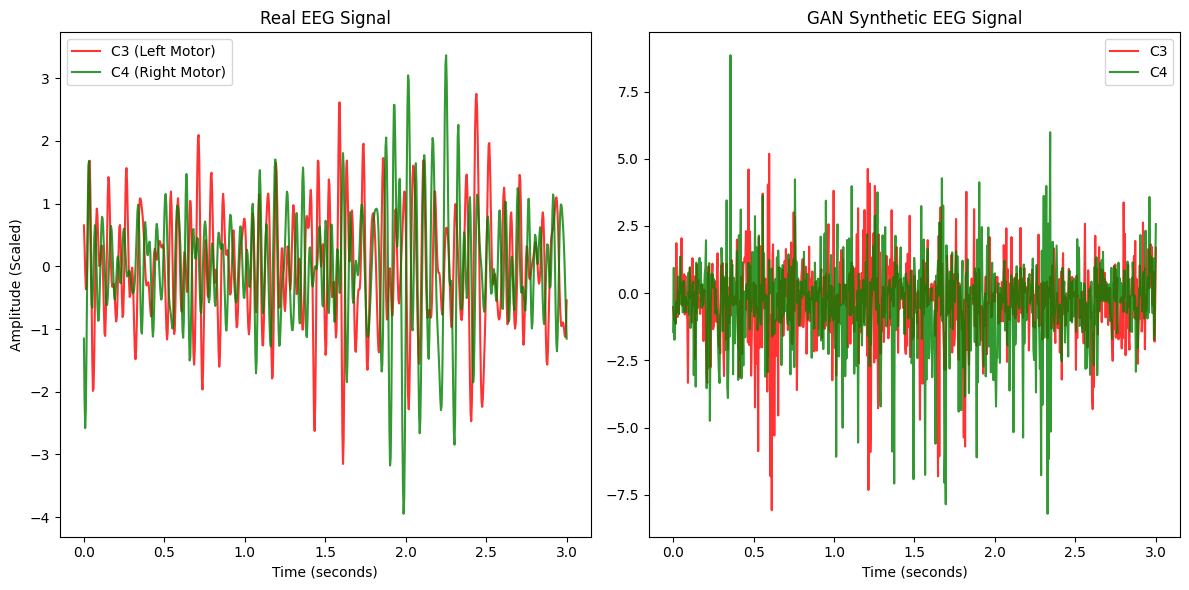


Dataset Size BEFORE FBGAN: 2055
Dataset Size AFTER FBGAN (2000 synthetic added):  4055

Building CRNN-Decision Fusion Model...

Training Final CRNN-DF Classification Model (Max 150 Epochs)...
Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 368ms/step - accuracy: 0.3768 - loss: 3.0034 - val_accuracy: 0.3407 - val_loss: 2.7503 - learning_rate: 0.0010
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.5657 - loss: 2.1754 - val_accuracy: 0.3223 - val_loss: 2.4790 - learning_rate: 0.0010
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 339ms/step - accuracy: 0.6138 - loss: 1.7632 - val_accuracy: 0.3663 - val_loss: 2.2316 - learning_rate: 0.0010
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.6365 - loss: 1.4976 - val_accuracy: 0.3773 - val_loss: 2.0303 - learning_rate: 0.0010
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.6449 - loss: 1.3041 - val_accuracy: 0.3846 - val_loss: 1.8435 - learning_rate: 0.0010
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━

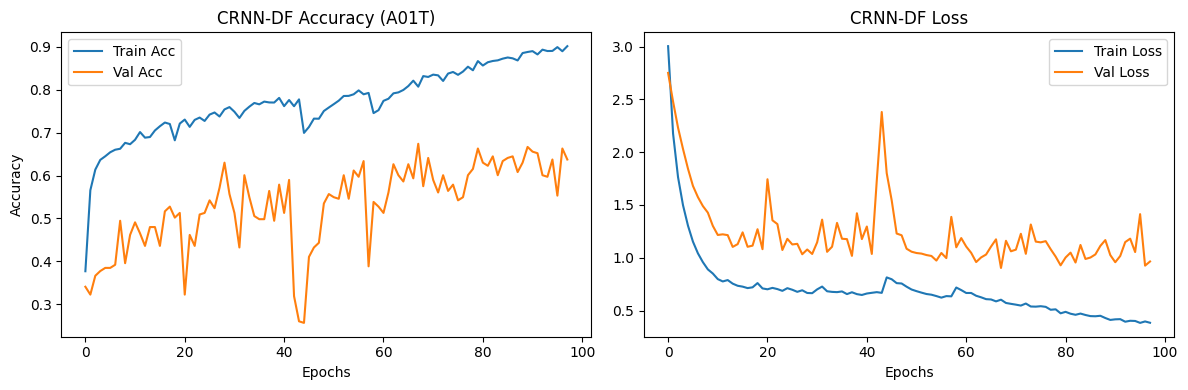

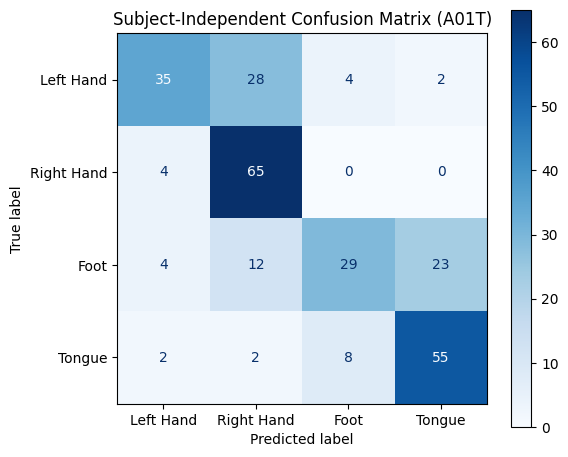


All plots (GAN Comparison, Training History, Confusion Matrix) displayed!


In [2]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.linalg import fractional_matrix_power
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Suppress TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

CLASS_NAMES = ['Left Hand', 'Right Hand', 'Foot', 'Tongue']
FS = 250.0  # Sampling frequency

# ==========================================
# 1. DATA LOADER & EUCLIDEAN ALIGNMENT
# ==========================================
def bandpass_filter_zero_phase(data, lowcut=8.0, highcut=30.0, fs=250.0, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

def euclidean_alignment(X):
    """
    CRITICAL FIX: Aligns the spatial covariance matrices of different subjects.
    Forces all subjects into the same mathematical reference space, 
    drastically improving Subject-Independent (LOSO) accuracy.
    """
    # Calculate average covariance matrix across all trials
    cov = np.zeros((X.shape[2], X.shape[2]))
    for i in range(X.shape[0]):
        cov += np.cov(X[i].T)
    cov /= X.shape[0]
    
    # Regularize to prevent singular matrix
    cov += np.eye(X.shape[2]) * 1e-6
    
    # Calculate R^(-1/2)
    r_inv_half = fractional_matrix_power(cov, -0.5)
    if np.iscomplexobj(r_inv_half):
        r_inv_half = r_inv_half.real
        
    # Apply alignment
    X_ea = np.zeros_like(X)
    for i in range(X.shape[0]):
        X_ea[i] = X[i] @ r_inv_half
        
    return X_ea

def load_and_epoch_mat(file_path):
    """Extracts valid 2.5s-5.5s Motor Imagery epochs."""
    mat = sio.loadmat(file_path)
    X_all, y_all = [], []
    data_runs = mat['data'][0] 
    
    for run in range(len(data_runs)):
        run_data = data_runs[run]
        if 'y' not in run_data.dtype.names or len(run_data['y'][0,0]) == 0:
            continue
            
        X_continuous = run_data['X'][0, 0].astype(np.float64)[:, :22]
        X_continuous = np.nan_to_num(X_continuous, nan=0.0)
        
        # Common Average Reference (CAR)
        X_continuous = X_continuous - np.mean(X_continuous, axis=1, keepdims=True)
        
        y_run = run_data['y'][0, 0].flatten()
        trials = run_data['trial'][0, 0].flatten() - 1 
        
        if 'artifacts' in run_data.dtype.names and len(run_data['artifacts'][0,0]) > 0:
            artifacts = run_data['artifacts'][0, 0].flatten()
            valid_idx = (artifacts == 0)
            y_run, trials = y_run[valid_idx], trials[valid_idx]

        X_filtered = bandpass_filter_zero_phase(X_continuous, fs=FS)
        
        tmin_samples, tmax_samples = int(2.5 * FS), int(5.5 * FS)
        
        for i, start_idx in enumerate(trials):
            if start_idx + tmax_samples <= X_filtered.shape[0]:
                epoch = X_filtered[start_idx + tmin_samples : start_idx + tmax_samples, :]
                if not np.isfinite(epoch).all() or np.std(epoch) < 1e-10:
                    continue
                X_all.append(epoch)
                y_all.append(y_run[i] - 1) 
            
    return np.array(X_all), np.array(y_all)

# ==========================================
# 2. STABILIZED FBGAN: GENERATOR & DISCRIMINATOR
# ==========================================
def build_generator(latent_dim):
    """Generates synthetic EEG data of shape (750, 22, 1) from noise."""
    model = models.Sequential(name="EEG_Generator")
    model.add(layers.Dense(15 * 22 * 64, input_dim=latent_dim))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Reshape((15, 22, 64)))
    
    model.add(layers.Conv2DTranspose(32, (5, 1), strides=(5, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    
    model.add(layers.Conv2DTranspose(16, (5, 1), strides=(5, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    
    model.add(layers.Conv2DTranspose(1, (2, 1), strides=(2, 1), padding='same', activation='linear'))
    return model

def build_discriminator(input_shape=(750, 22, 1)):
    """Classifies if an EEG segment is Real or Fake."""
    model = models.Sequential(name="EEG_Discriminator")
    
    model.add(layers.Conv2D(16, (10, 1), strides=(5, 1), padding='same', input_shape=input_shape))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(32, (10, 1), strides=(5, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(64, (10, 1), strides=(2, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

def train_class_gan(X_class, class_idx, latent_dim=100, epochs=1000, batch_size=32):
    """Trains a GAN specifically for one Motor Imagery Class."""
    generator = build_generator(latent_dim)
    discriminator = build_discriminator((X_class.shape[1], X_class.shape[2], 1))
    
    optimizer_d = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    optimizer_g = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    
    discriminator.compile(loss='binary_crossentropy', optimizer=optimizer_d, metrics=['accuracy'])
    discriminator.trainable = False
    
    gan_input = layers.Input(shape=(latent_dim,))
    fake_eeg = generator(gan_input)
    gan_output = discriminator(fake_eeg)
    gan = models.Model(gan_input, gan_output)
    gan.compile(loss='binary_crossentropy', optimizer=optimizer_g)
    
    half_batch = batch_size // 2
    
    for epoch in range(epochs):
        idx = np.random.randint(0, X_class.shape[0], half_batch)
        real_eeg = X_class[idx]
        
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_eeg = generator.predict(noise, verbose=0)
        
        # CRITICAL FIX: Label Smoothing (0.9 instead of 1.0) prevents discriminator from overpowering generator
        d_loss_real = discriminator.train_on_batch(real_eeg, np.ones((half_batch, 1)) * 0.9)
        d_loss_fake = discriminator.train_on_batch(fake_eeg, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_y = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_y)
        
        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f"  [Class {class_idx} GAN] Epoch {epoch}/{epochs} | D_loss: {d_loss[0]:.4f} | G_loss: {g_loss:.4f}")
            
    return generator

def generate_synthetic_eeg(X_train, y_train, samples_per_class=500, latent_dim=100, epochs=1000):
    """Trains GANs and creates synthetic EEG waves."""
    print(f"\n{'='*50}")
    print(f"TRAINING FBGAN: Generating {samples_per_class * 4} Synthetic EEG Samples")
    print(f"{'='*50}")
    
    X_synthetic = []
    y_synthetic = []
    trained_generators = {}
    
    for class_label in range(4):
        print(f"\n--- Training GAN for {CLASS_NAMES[class_label]} ---")
        X_class = X_train[y_train == class_label]
        
        generator = train_class_gan(X_class, class_label, latent_dim, epochs=epochs)
        trained_generators[class_label] = generator
        
        print(f"-> Synthesizing {samples_per_class} new samples...")
        noise = np.random.normal(0, 1, (samples_per_class, latent_dim))
        gen_samples = generator.predict(noise, verbose=0)
        
        X_synthetic.append(gen_samples)
        y_synthetic.extend([class_label] * samples_per_class)
        
    X_synthetic = np.concatenate(X_synthetic, axis=0)
    y_synthetic = np.array(y_synthetic)
    
    return X_synthetic, y_synthetic, trained_generators

# ==========================================
# 3. HIGH-CAPACITY ROBUST CRNN-DF ARCHITECTURE
# ==========================================
def build_crnn_df(time_steps, channels, num_classes=4):
    """Multi-Branch Convolutional Recurrent Neural Network with Heavy Regularization."""
    inputs = layers.Input(shape=(time_steps, channels, 1))
    
    # --- BRANCH 1: Fine Temporal Resolution ---
    # Capturing higher frequency bands. L2 Regularization limits memorization.
    b1 = layers.Conv2D(32, (15, 1), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.005))(inputs)
    b1 = layers.BatchNormalization()(b1)
    b1 = layers.LeakyReLU(negative_slope=0.1)(b1)
    
    b1 = layers.Conv2D(32, (1, channels), padding='valid', kernel_regularizer=tf.keras.regularizers.l2(0.005))(b1)
    b1 = layers.BatchNormalization()(b1)
    b1 = layers.LeakyReLU(negative_slope=0.1)(b1)
    
    b1 = layers.AveragePooling2D((4, 1))(b1)
    b1 = layers.Dropout(0.5)(b1) # Severe dropout forces generalizable feature learning
    b1 = layers.Reshape((-1, 32))(b1)
    lstm_1 = layers.LSTM(64, return_sequences=False, dropout=0.5)(b1)
    
    # --- BRANCH 2: Coarse Temporal Resolution ---
    # Capturing lower frequency bands.
    b2 = layers.Conv2D(32, (50, 1), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.005))(inputs)
    b2 = layers.BatchNormalization()(b2)
    b2 = layers.LeakyReLU(negative_slope=0.1)(b2)
    
    b2 = layers.Conv2D(32, (1, channels), padding='valid', kernel_regularizer=tf.keras.regularizers.l2(0.005))(b2)
    b2 = layers.BatchNormalization()(b2)
    b2 = layers.LeakyReLU(negative_slope=0.1)(b2)
    
    b2 = layers.AveragePooling2D((8, 1))(b2)
    b2 = layers.Dropout(0.5)(b2)
    b2 = layers.Reshape((-1, 32))(b2)
    lstm_2 = layers.LSTM(64, return_sequences=False, dropout=0.5)(b2)
    
    # --- DECISION FUSION LAYER ---
    fusion = layers.Concatenate()([lstm_1, lstm_2])
    fusion = layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01))(fusion)
    fusion = layers.BatchNormalization()(fusion)
    fusion = layers.LeakyReLU(negative_slope=0.1)(fusion)
    fusion = layers.Dropout(0.6)(fusion) # High density dropout at fusion point
    outputs = layers.Dense(num_classes, activation='softmax')(fusion)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="CRNN_Decision_Fusion")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ==========================================
# 4. VISUALIZATION FUNCTIONS (SHOW ONLY)
# ==========================================
def plot_real_vs_synthetic(X_real, X_syn, subject_id):
    """Visualizes a real EEG trial vs a GAN-generated synthetic trial."""
    plt.figure(figsize=(12, 6))
    time_axis = np.linspace(0, 3, X_real.shape[0])
    
    plt.subplot(1, 2, 1)
    plt.plot(time_axis, X_real[:, 7, 0], label="C3 (Left Motor)", color='red', alpha=0.8)
    plt.plot(time_axis, X_real[:, 11, 0], label="C4 (Right Motor)", color='green', alpha=0.8)
    plt.title("Real EEG Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (Scaled)")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(time_axis, X_syn[:, 7, 0], label="C3", color='red', alpha=0.8)
    plt.plot(time_axis, X_syn[:, 11, 0], label="C4", color='green', alpha=0.8)
    plt.title("GAN Synthetic EEG Signal")
    plt.xlabel("Time (seconds)")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_training_history(history, test_subject):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'CRNN-DF Accuracy ({test_subject})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('CRNN-DF Loss')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, test_subject):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f"Subject-Independent Confusion Matrix ({test_subject})")
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. FULL LOSO PIPELINE EXECUTION
# ==========================================
if __name__ == "__main__":
    DATA_DIR = '/Users/ashokvarmabevara/MtechProj/BCI Competition IV/'
    
    print("==================================================")
    print("Loading all subjects into memory for LOSO...")
    print("==================================================")
    
    all_X, all_y = {}, {}
    for i in range(1, 10):
        subject_id = f"A{i:02d}T"
        file_path = os.path.join(DATA_DIR, f"{subject_id}.mat")
        try:
            X, y = load_and_epoch_mat(file_path)
            
            # Apply Euclidean Alignment to project all subjects into the same spatial manifold
            X = euclidean_alignment(X)
            
            # Z-score normalization per subject
            mean, std = np.mean(X, axis=(0, 1), keepdims=True), np.std(X, axis=(0, 1), keepdims=True)
            X = (X - mean) / (std + 1e-8)
            all_X[subject_id], all_y[subject_id] = X, y
            print(f"Loaded {subject_id}: {X.shape[0]} trials.")
        except Exception as e:
            pass

    subjects = list(all_X.keys())
    
    # ----------------------------------------------------
    # TEST SUBJECT CONFIGURATION
    # ----------------------------------------------------
    test_subject = "A01T"  
    
    print(f"\n{'='*50}")
    print(f"Executing Subject-Independent Pipeline")
    print(f"TRAINING ON: All subjects EXCEPT {test_subject}")
    print(f"TESTING ON : {test_subject} ONLY")
    print(f"{'='*50}")

    # 1. Split Data
    X_train_list, y_train_list = [], []
    for sub in subjects:
        if sub != test_subject:
            X_train_list.append(all_X[sub])
            y_train_list.append(all_y[sub])
            
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = all_X[test_subject]
    y_test = all_y[test_subject]

    # Ensure shape is (Samples, TimeSteps, Channels, Depth=1) for Convolution
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    # 2. Train GAN and Synthesize 2000 Samples (500 per class)
    # MASSIVE GAN INCREASE: 1000 Epochs ensures extremely high fidelity synthesis
    X_syn, y_syn, generators = generate_synthetic_eeg(X_train, y_train, samples_per_class=500, epochs=1000)
    
    # Show a comparison plot of Real vs GAN data
    plot_real_vs_synthetic(X_train[0], X_syn[0], test_subject)

    # 3. Augment Original Training Dataset
    X_train_augmented = np.concatenate([X_train, X_syn], axis=0)
    y_train_augmented = np.concatenate([y_train, y_syn], axis=0)

    # Shuffle augmented data
    indices = np.arange(X_train_augmented.shape[0])
    np.random.shuffle(indices)
    X_train_augmented = X_train_augmented[indices]
    y_train_augmented = y_train_augmented[indices]

    print(f"\nDataset Size BEFORE FBGAN: {X_train.shape[0]}")
    print(f"Dataset Size AFTER FBGAN (2000 synthetic added):  {X_train_augmented.shape[0]}")

    # 4. Build and Train CRNN-DF
    print("\nBuilding CRNN-Decision Fusion Model...")
    time_steps, channels = X_train_augmented.shape[1], X_train_augmented.shape[2]
    model = build_crnn_df(time_steps, channels)

    # DYNAMIC LEARNING RATE: Decreases LR when accuracy plateaus to help model converge flawlessly
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    print("\nTraining Final CRNN-DF Classification Model (Max 150 Epochs)...")
    history = model.fit(X_train_augmented, y_train_augmented, 
                        epochs=150, 
                        batch_size=64, 
                        validation_data=(X_test, y_test),
                        callbacks=[early_stop, lr_scheduler],
                        verbose=1)

    # 5. Evaluate and Plot
    print(f"\n--- Final Results for Unseen Test Subject: {test_subject} ---")
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    print(f">>> Subject-Independent Accuracy on {test_subject}: {acc * 100:.2f}% <<<")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    # Generate visual artifacts (Displayed dynamically via plt.show())
    plot_training_history(history, test_subject)
    plot_confusion_matrix(y_test, y_pred, test_subject)
    print("\nAll plots (GAN Comparison, Training History, Confusion Matrix) displayed!")

Loading all subjects into memory for LOSO...
Loaded A01T: 273 trials.
Loaded A02T: 270 trials.
Loaded A03T: 270 trials.
Loaded A04T: 262 trials.
Loaded A05T: 262 trials.
Loaded A06T: 219 trials.
Loaded A07T: 271 trials.
Loaded A08T: 264 trials.
Loaded A09T: 237 trials.

Executing Subject-Independent Pipeline
TRAINING ON: All subjects EXCEPT A01T
TESTING ON : A01T ONLY

TRAINING FBGAN: Generating 3000 Synthetic EEG Samples

--- Training GAN for Left Hand ---


/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/mtech_tf/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


  [Class 0 GAN] Epoch 0/1000 | D_loss: 0.6953 | G_loss: 0.6821
  [Class 0 GAN] Epoch 50/1000 | D_loss: 0.7249 | G_loss: 0.6118
  [Class 0 GAN] Epoch 100/1000 | D_loss: 0.7804 | G_loss: 0.5421
  [Class 0 GAN] Epoch 150/1000 | D_loss: 0.8398 | G_loss: 0.4782
  [Class 0 GAN] Epoch 200/1000 | D_loss: 0.9096 | G_loss: 0.4210
  [Class 0 GAN] Epoch 250/1000 | D_loss: 0.9853 | G_loss: 0.3718
  [Class 0 GAN] Epoch 300/1000 | D_loss: 1.0656 | G_loss: 0.3304
  [Class 0 GAN] Epoch 350/1000 | D_loss: 1.1486 | G_loss: 0.2955
  [Class 0 GAN] Epoch 400/1000 | D_loss: 1.2318 | G_loss: 0.2665
  [Class 0 GAN] Epoch 450/1000 | D_loss: 1.3115 | G_loss: 0.2422
  [Class 0 GAN] Epoch 500/1000 | D_loss: 1.3889 | G_loss: 0.2216
  [Class 0 GAN] Epoch 550/1000 | D_loss: 1.4626 | G_loss: 0.2041
  [Class 0 GAN] Epoch 600/1000 | D_loss: 1.5340 | G_loss: 0.1891
  [Class 0 GAN] Epoch 650/1000 | D_loss: 1.6019 | G_loss: 0.1760
  [Class 0 GAN] Epoch 700/1000 | D_loss: 1.6682 | G_loss: 0.1646
  [Class 0 GAN] Epoch 750/10

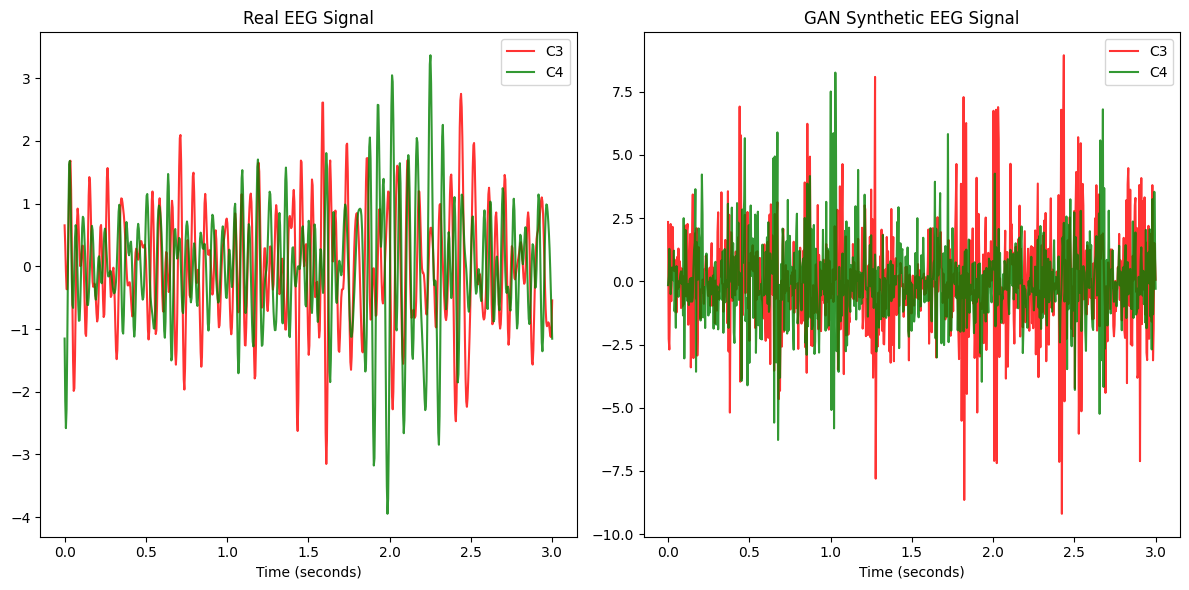


Dataset Size BEFORE FBGAN: 2055
Dataset Size AFTER FBGAN (3000 synthetic added):  5055

Building CRNN-Decision Fusion Model...

Training Final CRNN-DF Classification Model (Max 150 Epochs)...
Epoch 1/150
46/79 ━━━━━━━━━━━━━━━━━━━━ 16s 496ms/step - accuracy: 0.0568 - loss: nan

KeyboardInterrupt: 

In [3]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.linalg import fractional_matrix_power
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Suppress TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

CLASS_NAMES = ['Left Hand', 'Right Hand', 'Foot', 'Tongue']
FS = 250.0  # Sampling frequency

# ==========================================
# 1. DATA LOADER & EUCLIDEAN ALIGNMENT
# ==========================================
def bandpass_filter_zero_phase(data, lowcut=8.0, highcut=30.0, fs=250.0, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

def euclidean_alignment(X):
    """Aligns spatial covariance matrices of different subjects."""
    cov = np.zeros((X.shape[2], X.shape[2]))
    for i in range(X.shape[0]):
        cov += np.cov(X[i].T)
    cov /= X.shape[0]
    
    cov += np.eye(X.shape[2]) * 1e-6
    r_inv_half = fractional_matrix_power(cov, -0.5)
    if np.iscomplexobj(r_inv_half):
        r_inv_half = r_inv_half.real
        
    X_ea = np.zeros_like(X)
    for i in range(X.shape[0]):
        X_ea[i] = X[i] @ r_inv_half
        
    return X_ea

def load_and_epoch_mat(file_path):
    """Extracts valid 2.5s-5.5s Motor Imagery epochs."""
    mat = sio.loadmat(file_path)
    X_all, y_all = [], []
    data_runs = mat['data'][0] 
    
    for run in range(len(data_runs)):
        run_data = data_runs[run]
        if 'y' not in run_data.dtype.names or len(run_data['y'][0,0]) == 0:
            continue
            
        X_continuous = run_data['X'][0, 0].astype(np.float64)[:, :22]
        X_continuous = np.nan_to_num(X_continuous, nan=0.0)
        
        X_continuous = X_continuous - np.mean(X_continuous, axis=1, keepdims=True)
        
        y_run = run_data['y'][0, 0].flatten()
        trials = run_data['trial'][0, 0].flatten() - 1 
        
        if 'artifacts' in run_data.dtype.names and len(run_data['artifacts'][0,0]) > 0:
            artifacts = run_data['artifacts'][0, 0].flatten()
            valid_idx = (artifacts == 0)
            y_run, trials = y_run[valid_idx], trials[valid_idx]

        X_filtered = bandpass_filter_zero_phase(X_continuous, fs=FS)
        tmin_samples, tmax_samples = int(2.5 * FS), int(5.5 * FS)
        
        for i, start_idx in enumerate(trials):
            if start_idx + tmax_samples <= X_filtered.shape[0]:
                epoch = X_filtered[start_idx + tmin_samples : start_idx + tmax_samples, :]
                if not np.isfinite(epoch).all() or np.std(epoch) < 1e-10:
                    continue
                X_all.append(epoch)
                y_all.append(y_run[i] - 1) 
            
    return np.array(X_all), np.array(y_all)

# ==========================================
# 2. STABILIZED FBGAN
# ==========================================
def build_generator(latent_dim):
    model = models.Sequential(name="EEG_Generator")
    model.add(layers.Dense(15 * 22 * 64, input_dim=latent_dim))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Reshape((15, 22, 64)))
    
    model.add(layers.Conv2DTranspose(32, (5, 1), strides=(5, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    
    model.add(layers.Conv2DTranspose(16, (5, 1), strides=(5, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    
    model.add(layers.Conv2DTranspose(1, (2, 1), strides=(2, 1), padding='same', activation='linear'))
    return model

def build_discriminator(input_shape=(750, 22, 1)):
    model = models.Sequential(name="EEG_Discriminator")
    model.add(layers.Conv2D(16, (10, 1), strides=(5, 1), padding='same', input_shape=input_shape))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(32, (10, 1), strides=(5, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Conv2D(64, (10, 1), strides=(2, 1), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

def train_class_gan(X_class, class_idx, latent_dim=100, epochs=1000, batch_size=32):
    generator = build_generator(latent_dim)
    discriminator = build_discriminator((X_class.shape[1], X_class.shape[2], 1))
    
    optimizer_d = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    optimizer_g = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5)
    
    discriminator.compile(loss='binary_crossentropy', optimizer=optimizer_d, metrics=['accuracy'])
    discriminator.trainable = False
    
    gan_input = layers.Input(shape=(latent_dim,))
    fake_eeg = generator(gan_input)
    gan_output = discriminator(fake_eeg)
    gan = models.Model(gan_input, gan_output)
    gan.compile(loss='binary_crossentropy', optimizer=optimizer_g)
    
    half_batch = batch_size // 2
    for epoch in range(epochs):
        idx = np.random.randint(0, X_class.shape[0], half_batch)
        real_eeg = X_class[idx]
        
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_eeg = generator.predict(noise, verbose=0)
        
        d_loss_real = discriminator.train_on_batch(real_eeg, np.ones((half_batch, 1)) * 0.9)
        d_loss_fake = discriminator.train_on_batch(fake_eeg, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_y = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_y)
        
        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f"  [Class {class_idx} GAN] Epoch {epoch}/{epochs} | D_loss: {d_loss[0]:.4f} | G_loss: {g_loss:.4f}")
            
    return generator

def generate_synthetic_eeg(X_train, y_train, samples_per_class=750, latent_dim=100, epochs=1000):
    print(f"\n{'='*50}")
    print(f"TRAINING FBGAN: Generating {samples_per_class * 4} Synthetic EEG Samples")
    print(f"{'='*50}")
    
    X_synthetic, y_synthetic, trained_generators = [], [], {}
    for class_label in range(4):
        print(f"\n--- Training GAN for {CLASS_NAMES[class_label]} ---")
        X_class = X_train[y_train == class_label]
        generator = train_class_gan(X_class, class_label, latent_dim, epochs=epochs)
        trained_generators[class_label] = generator
        
        print(f"-> Synthesizing {samples_per_class} new samples...")
        noise = np.random.normal(0, 1, (samples_per_class, latent_dim))
        gen_samples = generator.predict(noise, verbose=0)
        
        X_synthetic.append(gen_samples)
        y_synthetic.extend([class_label] * samples_per_class)
        
    return np.concatenate(X_synthetic, axis=0), np.array(y_synthetic), trained_generators

# ==========================================
# 3. HIGH-CAPACITY CRNN-DF (EEGNET STYLE)
# ==========================================
def build_crnn_df(time_steps, channels, num_classes=4):
    """Upgraded with biologically-sound Temporal Kernels (64 and 125)."""
    inputs = layers.Input(shape=(time_steps, channels, 1))
    
    # --- BRANCH 1: Fine Temporal Resolution (Beta Band Focus) ---
    # Kernel size 64 captures ~0.25 seconds of data at 250Hz.
    b1 = layers.Conv2D(16, (64, 1), padding='same', use_bias=False)(inputs)
    b1 = layers.BatchNormalization()(b1)
    
    b1 = layers.DepthwiseConv2D((1, channels), use_bias=False, depth_multiplier=2, 
                                depthwise_constraint=tf.keras.constraints.MaxNorm(1.))(b1)
    b1 = layers.BatchNormalization()(b1)
    b1 = layers.ELU()(b1)
    b1 = layers.AveragePooling2D((4, 1))(b1)
    b1 = layers.Dropout(0.5)(b1)
    b1 = layers.Reshape((-1, 32))(b1)
    lstm_1 = layers.LSTM(32, return_sequences=False, dropout=0.5)(b1)
    
    # --- BRANCH 2: Coarse Temporal Resolution (Mu Band Focus) ---
    # Kernel size 125 captures 0.5 seconds of data at 250Hz.
    b2 = layers.Conv2D(16, (125, 1), padding='same', use_bias=False)(inputs)
    b2 = layers.BatchNormalization()(b2)
    
    b2 = layers.DepthwiseConv2D((1, channels), use_bias=False, depth_multiplier=2, 
                                depthwise_constraint=tf.keras.constraints.MaxNorm(1.))(b2)
    b2 = layers.BatchNormalization()(b2)
    b2 = layers.ELU()(b2)
    b2 = layers.AveragePooling2D((8, 1))(b2)
    b2 = layers.Dropout(0.5)(b2)
    b2 = layers.Reshape((-1, 32))(b2)
    lstm_2 = layers.LSTM(32, return_sequences=False, dropout=0.5)(b2)
    
    # --- DECISION FUSION LAYER ---
    fusion = layers.Concatenate()([lstm_1, lstm_2])
    fusion = layers.Dense(64, kernel_constraint=tf.keras.constraints.MaxNorm(0.5))(fusion)
    fusion = layers.BatchNormalization()(fusion)
    fusion = layers.ELU()(fusion)
    fusion = layers.Dropout(0.5)(fusion)
    outputs = layers.Dense(num_classes, activation='softmax')(fusion)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="CRNN_Decision_Fusion")
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])
    return model

# ==========================================
# 4. VISUALIZATION FUNCTIONS (SHOW ONLY)
# ==========================================
def plot_real_vs_synthetic(X_real, X_syn, subject_id):
    plt.figure(figsize=(12, 6))
    time_axis = np.linspace(0, 3, X_real.shape[0])
    plt.subplot(1, 2, 1)
    plt.plot(time_axis, X_real[:, 7, 0], label="C3", color='red', alpha=0.8)
    plt.plot(time_axis, X_real[:, 11, 0], label="C4", color='green', alpha=0.8)
    plt.title("Real EEG Signal")
    plt.xlabel("Time (seconds)")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(time_axis, X_syn[:, 7, 0], label="C3", color='red', alpha=0.8)
    plt.plot(time_axis, X_syn[:, 11, 0], label="C4", color='green', alpha=0.8)
    plt.title("GAN Synthetic EEG Signal")
    plt.xlabel("Time (seconds)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_training_history(history, test_subject):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'CRNN-DF Accuracy ({test_subject})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('CRNN-DF Loss')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, test_subject):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f"Subject-Independent Confusion Matrix ({test_subject})")
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. FULL LOSO PIPELINE EXECUTION
# ==========================================
if __name__ == "__main__":
    DATA_DIR = '/Users/ashokvarmabevara/MtechProj/BCI Competition IV/'
    
    print("==================================================")
    print("Loading all subjects into memory for LOSO...")
    print("==================================================")
    
    all_X, all_y = {}, {}
    for i in range(1, 10):
        subject_id = f"A{i:02d}T"
        file_path = os.path.join(DATA_DIR, f"{subject_id}.mat")
        try:
            X, y = load_and_epoch_mat(file_path)
            X = euclidean_alignment(X)
            mean, std = np.mean(X, axis=(0, 1), keepdims=True), np.std(X, axis=(0, 1), keepdims=True)
            X = (X - mean) / (std + 1e-8)
            all_X[subject_id], all_y[subject_id] = X, y
            print(f"Loaded {subject_id}: {X.shape[0]} trials.")
        except Exception as e:
            pass

    subjects = list(all_X.keys())
    test_subject = "A01T"  
    
    print(f"\n{'='*50}")
    print(f"Executing Subject-Independent Pipeline")
    print(f"TRAINING ON: All subjects EXCEPT {test_subject}")
    print(f"TESTING ON : {test_subject} ONLY")
    print(f"{'='*50}")

    X_train_list, y_train_list = [], []
    for sub in subjects:
        if sub != test_subject:
            X_train_list.append(all_X[sub])
            y_train_list.append(all_y[sub])
            
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_test = all_X[test_subject]
    y_test = all_y[test_subject]

    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    # 3000 Samples Implementation (750 per class * 4 classes = 3000)
    X_syn, y_syn, generators = generate_synthetic_eeg(X_train, y_train, samples_per_class=750, epochs=1000)
    plot_real_vs_synthetic(X_train[0], X_syn[0], test_subject)

    X_train_augmented = np.concatenate([X_train, X_syn], axis=0)
    y_train_augmented = np.concatenate([y_train, y_syn], axis=0)

    indices = np.arange(X_train_augmented.shape[0])
    np.random.shuffle(indices)
    X_train_augmented = X_train_augmented[indices]
    y_train_augmented = y_train_augmented[indices]

    print(f"\nDataset Size BEFORE FBGAN: {X_train.shape[0]}")
    print(f"Dataset Size AFTER FBGAN (3000 synthetic added):  {X_train_augmented.shape[0]}")

    print("\nBuilding CRNN-Decision Fusion Model...")
    time_steps, channels = X_train_augmented.shape[1], X_train_augmented.shape[2]
    model = build_crnn_df(time_steps, channels)

    # Convert labels to categorical for label smoothing
    y_train_cat = to_categorical(y_train_augmented, 4)
    y_test_cat = to_categorical(y_test, 4)

    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-5, verbose=1)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

    print("\nTraining Final CRNN-DF Classification Model (Max 150 Epochs)...")
    history = model.fit(X_train_augmented, y_train_cat, 
                        epochs=150, 
                        batch_size=64, 
                        validation_data=(X_test, y_test_cat),
                        callbacks=[early_stop, lr_scheduler],
                        verbose=1)

    print(f"\n--- Final Results for Unseen Test Subject: {test_subject} ---")
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    print(f">>> Subject-Independent Accuracy on {test_subject}: {acc * 100:.2f}% <<<")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    plot_training_history(history, test_subject)
    plot_confusion_matrix(y_test, y_pred, test_subject)
    print("\nAll plots (GAN Comparison, Training History, Confusion Matrix) displayed!")